# MarkScribe
### A Vision-Language Scriptorium - Qwen2-VL-2B fine-tuned with QLoRA to transcribe document images into Markdown


---


## What this notebook does

Fine-tunes the 2-billion-parameter vision-language model **Qwen2-VL-2B-Instruct** on the **Nougat** document-image -> Markdown corpus, using **QLoRA** (NF4 4-bit base + low-rank adapters) so it fits on a single T4 (16 GB). After training it generates Markdown for unseen pages and ships an interactive Gradio app.

## Hyperparameters at a glance

| | value | rationale |
|---|---|---|
| base model | Qwen2-VL-2B-Instruct | smallest Qwen2-VL with strong OCR |
| quant | NF4 + double-quant, bf16 compute | fits on 16 GB |
| LoRA rank / alpha | 16 / 32 | within assignment band; alpha = 2*r |
| LoRA targets | q,k,v,o,gate,up,down (LM only) | vision tower stays frozen |
| epochs | 5 (default) - bonus also runs 2 vs 5 | per spec |
| batch / grad-accum | 1 / 8 (effective 8) | T4 memory budget |
| lr / scheduler | 2e-4 / cosine, 3% warmup | per spec |
| optimiser | paged_adamw_8bit | keeps state off GPU |
| image long side | 768 px | per spec |
| split | 80 / 20 | per spec |

## Sections

| # | Section | Output |
|---|---------|--------|
| 0 | Setup | env / GPU info |
| 1 | Dataset Exploration | pair stats + sample grid |
| 2 | Data Prep (ChatML) | message-builder helper |
| 3 | Train / Val Split | 80 / 20 |
| 4 | QLoRA Fine-Tuning | trained adapter + loss curves |
| 5 | Markdown Generation (core) | predictions on val set |
| 6 | Testing | 3 train + 3 unseen predictions |
| 7 | Visualization | image / GT / prediction grid |
| 8 | Bonus 1 | 2 vs 5 epochs comparison |
| 9 | Bonus 2 | prompt-style ablation |
| 10 | Bonus 3 | zero-shot vs fine-tuned |
| 11 | Gradio App | shareable web UI |



## 0. Environment Setup

The cell below installs every dependency needed on a fresh Kaggle kernel. On Kaggle, `transformers`, `torch`, and `accelerate` are pre-installed but usually too old for Qwen2-VL - we pin compatible versions.

In [17]:
%%capture
# 1) Force-reinstall a clean, internally-consistent Pillow BEFORE anything else.
#    Kaggle's image often ships a half-upgraded PIL where ImageText.py imports
#    _Ink from _typing.py but _typing.py is older and doesn't define it.
#    Pillow 10.4.0 doesn't ship ImageText.py at all -> the broken path disappears.
!pip install -q --force-reinstall --no-deps "Pillow==10.4.0"

# 2) Now upgrade everything else (without touching Pillow again).
!pip install -q --upgrade \
    "transformers>=4.45.0" \
    "accelerate>=0.34.0" \
    "peft>=0.13.0" \
    "bitsandbytes>=0.44.0" \
    "datasets>=3.0.0" \
    "qwen-vl-utils" \
    "trl>=0.11.0" \
    "sentencepiece" \
    "matplotlib" \
    "tqdm" \
    "gradio>=4.44.0"


> **Restart the kernel after the install cell.** Run the cell below (it shuts the kernel down so Kaggle restarts it automatically), then skip the install cell and resume from the imports cell.

In [18]:
import os, sys, json, math, random, gc, time, glob, re
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"torch        : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name}  |  {p.total_memory/1e9:.1f} GB")


torch        : 2.10.0+cu128
CUDA available: True
  GPU 0: Tesla T4  |  15.6 GB
  GPU 1: Tesla T4  |  15.6 GB


In [19]:
# ----- Global configuration -----------------------------------------------------
MODEL_ID         = "Qwen/Qwen2-VL-2B-Instruct"
OUTPUT_DIR       = "./qwen2vl-nougat-qlora"
ADAPTER_DIR      = f"{OUTPUT_DIR}/adapter"

# Where the Nougat example dataset lives on Kaggle when attached:
KAGGLE_DATA_ROOT = "/kaggle/input/datasets/zphilip/nougat-training-dataset-example"
LOCAL_DATA_ROOT  = "./nougat-training-dataset-example"   # fallback for local dev

# Training hyper-parameters (tuned for T4 x 2)
TRAIN_CONFIG = dict(
    epochs             = 5,
    per_device_bs       = 1,
    grad_accum          = 8,
    lr                  = 2e-4,
    lora_rank           = 16,
    lora_alpha          = 32,
    lora_dropout        = 0.05,
    image_max_side      = 768,
    max_seq_len         = 2048,
    logging_steps       = 10,
    eval_steps          = 50,
    save_steps          = 100,
    warmup_ratio        = 0.03,
)

# Subset sizes (use small numbers first to validate pipeline, scale up after).
N_TRAIN = 200
N_VAL   = 40

INSTRUCTION_PROMPT = (
    "You are a document-understanding assistant. "
    "Convert the provided document image into clean, well-structured GitHub-flavored Markdown. "
    "Preserve headings, lists, tables, equations (use $...$ / $$...$$), and reading order. "
    "Output Markdown only - no commentary."
)

print("Config loaded.")


Config loaded.


## Part 1 - Dataset Exploration

Verified layout of `zphilip/nougat-training-dataset-example` (3.19 GB, 14,200 pairs):

```
nougat-training-dataset-example/
- 0508.jsonl                       # 50 MB, one JSON object per line:
                                   #   {"image": "0508/<paper>/<NN>.png",
                                   #    "markdown": "<inline mathpix-markdown>",
                                   #    "meta": [...] }
- 0508/
    - astro-ph0508001/             # one folder per arXiv paper
        - 01.png   01.mmd          # matched page-image / markdown pairs
        - 02.png   02.mmd
        ...
    - quant-ph0508208/
        ...
```

Note the markdown is stored **inline** inside `0508.jsonl` (NOT as a path to a `.mmd`). The `0508/<paper>/NN.mmd` files contain the same content - we use the JSONL because it's a single, canonical index.

Strategy: parse `0508.jsonl`, resolve each `image` path relative to the dataset root, and keep the `markdown` value as-is.


In [20]:
def find_data_root():
    for cand in (KAGGLE_DATA_ROOT, LOCAL_DATA_ROOT):
        if os.path.isdir(cand):
            return cand
    raise FileNotFoundError(
        "Could not find the Nougat dataset.  Attach the Kaggle dataset "
        "'zphilip/nougat-training-dataset-example' or download it locally."
    )

DATA_ROOT = find_data_root()
print("Data root:", DATA_ROOT)

# Some Kaggle uploads place everything under a single nested subfolder.
# Walk one level down if the root contains exactly one directory.
entries = [e for e in os.listdir(DATA_ROOT) if not e.startswith(".")]
if len(entries) == 1 and os.path.isdir(os.path.join(DATA_ROOT, entries[0])):
    DATA_ROOT = os.path.join(DATA_ROOT, entries[0])
    print("Descended into:", DATA_ROOT)


Data root: /kaggle/input/datasets/zphilip/nougat-training-dataset-example


In [21]:
# ---------------------------------------------------------------------------
# Loader 1 - canonical: parse any *.jsonl index in the dataset root.
# Each line: {"image": "0508/<paper>/<NN>.png", "markdown": "<inline md>", "meta": [...]}
# ---------------------------------------------------------------------------
def load_jsonl_index(root):
    rows = []
    jsonls = sorted(Path(root).glob("*.jsonl"))
    for idx_path in jsonls:
        kept = 0; skipped = 0
        with open(idx_path, encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                line = line.strip()
                if not line: continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    skipped += 1; continue
                img_rel = rec.get("image") or rec.get("image_path") or rec.get("img")
                md_val  = rec.get("markdown") or rec.get("text") or rec.get("md") or rec.get("mmd")
                if not (img_rel and md_val): skipped += 1; continue
                img_abs = (Path(root) / img_rel).resolve()
                if not img_abs.is_file(): skipped += 1; continue
                # markdown is INLINE content, not a path
                md_text = md_val.strip() if isinstance(md_val, str) else None
                if not md_text: skipped += 1; continue
                rows.append({"image": str(img_abs), "markdown": md_text})
                kept += 1
        print(f"  {idx_path.name}: kept {kept:,} | skipped {skipped:,}")
    return rows

# ---------------------------------------------------------------------------
# Loader 2 - fallback: walk the tree, pair <stem>.png with <stem>.mmd in same dir
# ---------------------------------------------------------------------------
IMAGE_EXTS = {".png", ".jpg", ".jpeg"}

def find_markdown_for(img_path):
    p = Path(img_path)
    for ext in (".mmd", ".md", ".txt"):
        cand = p.with_suffix(ext)
        if cand.is_file():
            return cand.read_text(encoding="utf-8", errors="ignore")
    return None

def walk_pair():
    rows = []
    for dp, _, fs in os.walk(DATA_ROOT):
        for f in fs:
            if Path(f).suffix.lower() in IMAGE_EXTS:
                ip = os.path.join(dp, f)
                md = find_markdown_for(ip)
                if md and md.strip():
                    rows.append({"image": ip, "markdown": md.strip()})
    return rows

# ---------------------------------------------------------------------------
# Try canonical JSONL first, fall back to directory walk.
# ---------------------------------------------------------------------------
pairs = load_jsonl_index(DATA_ROOT)
if pairs:
    print(f"Loaded {len(pairs):,} pairs from JSONL index.")
else:
    print("No usable JSONL index found - falling back to directory walk.")
    pairs = walk_pair()
    print(f"Walked {len(pairs):,} pairs from filesystem.")

if not pairs:
    raise RuntimeError("No paired (image, markdown) samples found - check dataset layout.")


  0508.jsonl: kept 14,197 | skipped 3
Loaded 14,197 pairs from JSONL index.


In [22]:
# ----- Quick statistics -----
md_lens = [len(p["markdown"]) for p in pairs]
print(f"Markdown char length - min {min(md_lens)} | mean {int(np.mean(md_lens))} | "
      f"median {int(np.median(md_lens))} | max {max(md_lens)}")

with Image.open(pairs[0]["image"]) as im:
    print(f"First image size: {im.size}, mode={im.mode}")

print("\n--- First markdown sample (truncated) ---")
print(pairs[0]["markdown"][:600] + ("..." if len(pairs[0]["markdown"]) > 600 else ""))


Markdown char length - min 1 | mean 3169 | median 2881 | max 59339
First image size: (816, 1056), mode=RGB

--- First markdown sample (truncated) ---
ground state is two-fold degenerate, and when \(B>B_{\text{th}}\) the ground state becomes non-degenerate and the corresponding wave function is given by

\[|\psi_{0}\rangle=|-\frac{1}{2},-1\rangle,\] (39)

which is obviously of no entanglement. Then, the ground-state negativity forms a platform when \(0<B<B_{\text{th}}\). The jump of negativity at \(B=B_{\text{th}}\) is due to the level crossing. For \(N>2\), the effects of magnetic fields on entanglement can be also explained by level crossing. For instance, for \(N=4\), there are two level crossing, and the entanglement displays two jumps.
...


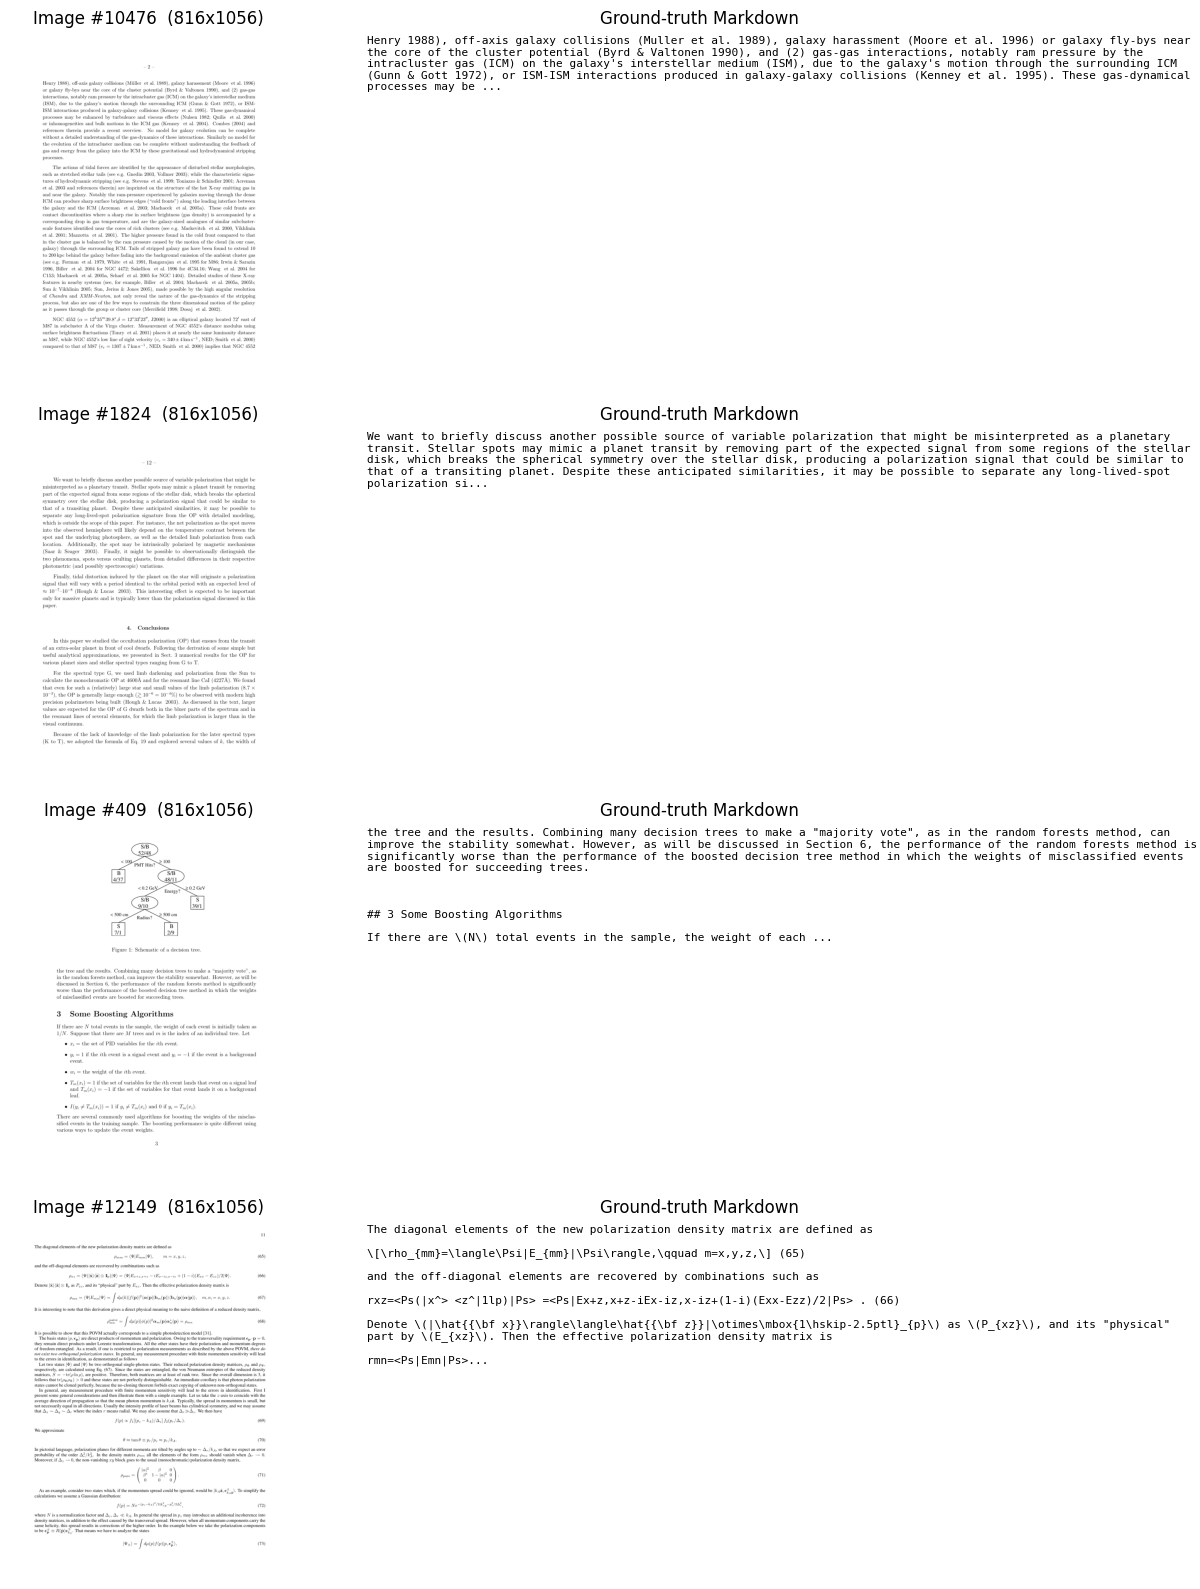

In [23]:
# ----- Visualise four random pairs --------------------------------------------
sample_idx = random.sample(range(len(pairs)), k=min(4, len(pairs)))
fig, axes = plt.subplots(len(sample_idx), 2, figsize=(14, 4*len(sample_idx)))
if len(sample_idx) == 1:
    axes = np.array([axes])

for row, idx in enumerate(sample_idx):
    img = Image.open(pairs[idx]["image"]).convert("RGB")
    axes[row, 0].imshow(img); axes[row, 0].axis("off")
    axes[row, 0].set_title(f"Image #{idx}  ({img.size[0]}x{img.size[1]})")
    snippet = pairs[idx]["markdown"][:500] + ("..." if len(pairs[idx]["markdown"]) > 500 else "")
    axes[row, 1].text(0.01, 0.99, snippet, family="monospace", fontsize=8,
                      va="top", ha="left", wrap=True)
    axes[row, 1].axis("off"); axes[row, 1].set_title("Ground-truth Markdown")
plt.tight_layout(); plt.show()


## Part 2 - Data Preparation (ChatML)

Qwen2-VL expects multi-turn messages where each user turn may contain mixed `image` and `text` content blocks. The processor's `apply_chat_template` builds the correct `<|vision_start|>...<|vision_end|>` markers.

Each training example becomes:

```python
[
  {"role": "user",      "content": [{"type": "image", "image": <PIL>},
                                    {"type": "text",  "text":  INSTRUCTION_PROMPT}]},
  {"role": "assistant", "content": [{"type": "text",  "text":  GROUND_TRUTH_MARKDOWN}]},
]
```

In [24]:
def resize_long_side(img, max_side):
    w, h = img.size
    s = max_side / max(w, h)
    if s >= 1.0:
        return img
    return img.resize((int(w*s), int(h*s)), Image.LANCZOS)

def build_messages(image_path, markdown=None, instruction=INSTRUCTION_PROMPT):
    """Build a Qwen2-VL ChatML message list. Pass markdown=None at inference time."""
    img = Image.open(image_path).convert("RGB")
    img = resize_long_side(img, TRAIN_CONFIG["image_max_side"])
    msgs = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text":  instruction},
        ],
    }]
    if markdown is not None:
        msgs.append({"role": "assistant",
                     "content": [{"type": "text", "text": markdown}]})
    return msgs

# Sanity check
demo_msgs = build_messages(pairs[0]["image"], pairs[0]["markdown"])
print(f"Built {len(demo_msgs)}-turn message; user content blocks = {len(demo_msgs[0]['content'])}")


Built 2-turn message; user content blocks = 2


## Part 3 - Train / Validation Split (80 / 20)

In [25]:
# Reproducible 80/20 split, but first verify each image actually decodes.
# The Nougat corpus contains a handful of corrupt/truncated PNGs (e.g.
# 0508/math0508359/03.png) that crash training when the collator hits them.
# Strategy: shuffle once, then pull the first N_TRAIN+N_VAL openable images.
random.Random(SEED).shuffle(pairs)

def is_openable(path):
    try:
        with Image.open(path) as im:
            im.convert("RGB")   # force a real decode, not just header check
        return True
    except Exception:
        return False

needed = N_TRAIN + N_VAL
clean, scanned, skipped = [], 0, 0
pbar = tqdm(pairs, desc="verifying images", total=needed, unit="img")
for p in pbar:
    scanned += 1
    if is_openable(p["image"]):
        clean.append(p)
        pbar.update(0)
        if len(clean) >= needed:
            break
    else:
        skipped += 1
pbar.close()
print(f"Scanned {scanned:,} pairs - kept {len(clean):,} | skipped {skipped:,} bad images.")

split = int(0.8 * len(clean))
train_pairs = clean[:split]
val_pairs   = clean[split:]
print(f"train = {len(train_pairs)}  |  val = {len(val_pairs)}")


verifying images:   0%|          | 0/240 [00:00<?, ?img/s]

Scanned 241 pairs - kept 240 | skipped 1 bad images.
train = 192  |  val = 48


## Part 4 - QLoRA Fine-Tuning

Steps:
1. **Quantize** the base Qwen2-VL-2B-Instruct to NF4 (4-bit) with double-quant.
2. **Freeze** every original parameter (`requires_grad = False`).
3. **Inject LoRA adapters** into the language-model attention + MLP projections (vision encoder is left untouched - it already understands images well; we only need to teach the LM to emit Markdown).
4. **Train** with `paged_adamw_8bit` to keep optimiser state off the 16 GB cards.

In [26]:
from transformers import (
    Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig,
    TrainingArguments, Trainer
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_use_double_quant = True,
    bnb_4bit_compute_dtype    = torch.bfloat16,
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
processor.image_processor.size = {"shortest_edge": 256, "longest_edge": TRAIN_CONFIG["image_max_side"]}

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config = bnb_config,
    device_map          = "auto",
    torch_dtype         = torch.bfloat16,
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
print("Base model loaded in 4-bit.")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Base model loaded in 4-bit.


In [27]:
lora_cfg = LoraConfig(
    r              = TRAIN_CONFIG["lora_rank"],
    lora_alpha     = TRAIN_CONFIG["lora_alpha"],
    lora_dropout   = TRAIN_CONFIG["lora_dropout"],
    bias           = "none",
    task_type      = "CAUSAL_LM",
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_cfg)

trainable, total = 0, 0
for n, p in model.named_parameters():
    total += p.numel()
    if p.requires_grad: trainable += p.numel()
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")


Trainable params: 18,464,768 / 1,240,740,352  (1.49%)


In [28]:
# ----- Custom collator for Qwen2-VL ----------------------------------------------
# We assemble the prompt, then mask everything *before* the assistant response so the
# loss is computed only on the markdown the model is supposed to generate.
# Bad images (rare) are skipped at runtime - the trainer will retry sampling.
IGNORE_INDEX = -100

class Qwen2VLCollator:
    def __init__(self, processor, max_len):
        self.processor = processor
        self.max_len   = max_len

    def _safe_open(self, path):
        try:
            return Image.open(path).convert("RGB")
        except Exception as e:
            print(f"[collator] dropping unreadable image: {path} ({e})")
            return None

    def __call__(self, batch_pairs):
        full_texts, prompt_texts, all_images = [], [], []
        for ex in batch_pairs:
            img = self._safe_open(ex["image"])
            if img is None:
                continue
            full_msgs   = build_messages(ex["image"], ex["markdown"])
            prompt_msgs = build_messages(ex["image"], None)
            full_texts.append(self.processor.apply_chat_template(
                full_msgs, tokenize=False, add_generation_prompt=False))
            prompt_texts.append(self.processor.apply_chat_template(
                prompt_msgs, tokenize=False, add_generation_prompt=True))
            all_images.append(img)

        if not all_images:
            # Whole batch was bad - return a dummy zero-loss batch so trainer continues.
            dummy = torch.zeros((1, 1), dtype=torch.long)
            return {"input_ids": dummy, "attention_mask": dummy,
                    "labels": torch.full_like(dummy, IGNORE_INDEX)}

        enc = self.processor(
            text          = full_texts,
            images        = all_images,
            padding       = True,
            truncation    = True,
            max_length    = self.max_len,
            return_tensors= "pt",
        )

        labels = enc.input_ids.clone()
        for i, ptxt in enumerate(prompt_texts):
            p_ids = self.processor.tokenizer(ptxt, add_special_tokens=False)["input_ids"]
            mask_len = min(len(p_ids), labels.size(1))
            labels[i, :mask_len] = IGNORE_INDEX
        labels[enc.input_ids == self.processor.tokenizer.pad_token_id] = IGNORE_INDEX
        enc["labels"] = labels
        return enc

collator = Qwen2VLCollator(processor, TRAIN_CONFIG["max_seq_len"])


In [29]:
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = TRAIN_CONFIG["epochs"],
    per_device_train_batch_size = TRAIN_CONFIG["per_device_bs"],
    per_device_eval_batch_size  = TRAIN_CONFIG["per_device_bs"],
    gradient_accumulation_steps = TRAIN_CONFIG["grad_accum"],
    learning_rate               = TRAIN_CONFIG["lr"],
    warmup_ratio                = TRAIN_CONFIG["warmup_ratio"],
    lr_scheduler_type           = "cosine",
    optim                       = "paged_adamw_8bit",
    bf16                        = True,
    gradient_checkpointing      = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    logging_steps               = TRAIN_CONFIG["logging_steps"],
    eval_strategy               = "steps",
    eval_steps                  = TRAIN_CONFIG["eval_steps"],
    save_strategy               = "steps",
    save_steps                  = TRAIN_CONFIG["save_steps"],
    save_total_limit            = 2,
    report_to                   = "none",
    remove_unused_columns       = False,
    dataloader_num_workers      = 2,
    seed                        = SEED,
    ddp_find_unused_parameters  = False,
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_pairs,
    eval_dataset  = val_pairs,
    data_collator = collator,
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [30]:
# ----- Train --------------------------------------------------------------------
train_result = trainer.train()
trainer.save_model(ADAPTER_DIR)
processor.save_pretrained(ADAPTER_DIR)
print("Adapter saved to:", ADAPTER_DIR)


Step,Training Loss,Validation Loss
50,1.718419,1.879988
100,1.399743,1.945153
120,1.470757,1.959101


Adapter saved to: ./qwen2vl-nougat-qlora/adapter


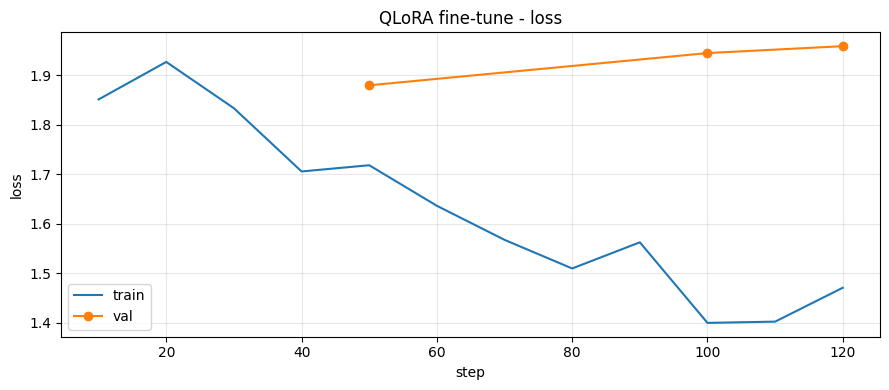

In [31]:
# ----- Plot loss curves ---------------------------------------------------------
hist = trainer.state.log_history
train_steps, train_losses = [], []
eval_steps,  eval_losses  = [], []
for h in hist:
    if "loss" in h and "step" in h and "eval_loss" not in h:
        train_steps.append(h["step"]); train_losses.append(h["loss"])
    if "eval_loss" in h:
        eval_steps.append(h["step"]); eval_losses.append(h["eval_loss"])

plt.figure(figsize=(9,4))
plt.plot(train_steps, train_losses, label="train")
if eval_losses:
    plt.plot(eval_steps, eval_losses, label="val", marker="o")
plt.xlabel("step"); plt.ylabel("loss"); plt.title("QLoRA fine-tune - loss")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Part 5 - Markdown Generation (Core Task)

Use the fine-tuned (adapter-augmented) model to convert validation images into Markdown, then compare against the ground truth.

In [32]:
@torch.inference_mode()
def generate_markdown(image_path, mdl=None, proc=None,
                      instruction=INSTRUCTION_PROMPT, max_new_tokens=1024):
    mdl  = mdl  or model
    proc = proc or processor
    msgs = build_messages(image_path, None, instruction)
    text = proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    image_inputs = [Image.open(image_path).convert("RGB")]
    inputs = proc(text=[text], images=image_inputs,
                  padding=True, return_tensors="pt").to(mdl.device)
    out_ids = mdl.generate(**inputs, max_new_tokens=max_new_tokens,
                           do_sample=False, temperature=0.0)
    trimmed = out_ids[0][inputs.input_ids.shape[1]:]
    return proc.tokenizer.decode(trimmed, skip_special_tokens=True).strip()


In [33]:
# ----- Run on a handful of validation samples -----
val_predictions = []
for ex in tqdm(val_pairs[:5], desc="generating"):
    pred = generate_markdown(ex["image"])
    val_predictions.append({"image": ex["image"],
                            "ground_truth": ex["markdown"],
                            "prediction": pred})

for r in val_predictions:
    print("="*80)
    print("IMG :", r["image"])
    print("GT  :", r["ground_truth"][:240], "...")
    print("PRED:", r["prediction"][:240], "...")


generating:   0%|          | 0/5 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


IMG : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/cond-mat0508043/02.png
GT  : speck ; ritort ; dhar ; peliti . Most of the experiments, for example those in the RNA stretching experiments of Liphardt et al lip or the more recent experiment of Douarche et al dour on torsionally driven mirrors, are in regimes where the ...
PRED: * [15] A. L. Alcaraz, M. A. Llave, and J. L. Martinez, Phys. Rev. Lett. **92**, 194001 (2004).
* [16] A. L. Alcaraz, M. A. Llave, and J. L. Martinez, Phys. Rev. Lett. **94**, 194001 (2005).
* [17] A. L. Alcaraz, M. A. Llave, and J. L. Marti ...
IMG : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/hep-ph0508094/16.png
GT  : \(a_{m}^{j}\), \(c_{m}^{j}\) and \(b_{m}^{j}\) which would be numerically calculated by an effective iteration method. In practical calculation, we take \(N_{ch,1}=32\), \(N_{ch,2}=6\), \(\Lambda=10\) GeV and \(\epsilon=0.01\) GeV (consider ...
PRED: # The \(S\)-matrix for the \(S\)-wave \(N\)-body 

## Part 6 - Testing on Training & Unseen Images

The assignment requires showing predictions for **3 training images** and **3 unseen images**.

In [34]:
train_test = random.sample(train_pairs, k=3)
val_test   = random.sample(val_pairs,   k=3)

train_results = [{"image": ex["image"], "ground_truth": ex["markdown"],
                  "prediction": generate_markdown(ex["image"])} for ex in tqdm(train_test, desc="train")]
val_results   = [{"image": ex["image"], "ground_truth": ex["markdown"],
                  "prediction": generate_markdown(ex["image"])} for ex in tqdm(val_test,   desc="unseen")]


train:   0%|          | 0/3 [00:00<?, ?it/s]

unseen:   0%|          | 0/3 [00:00<?, ?it/s]

## Visualization Module - image . ground truth . prediction

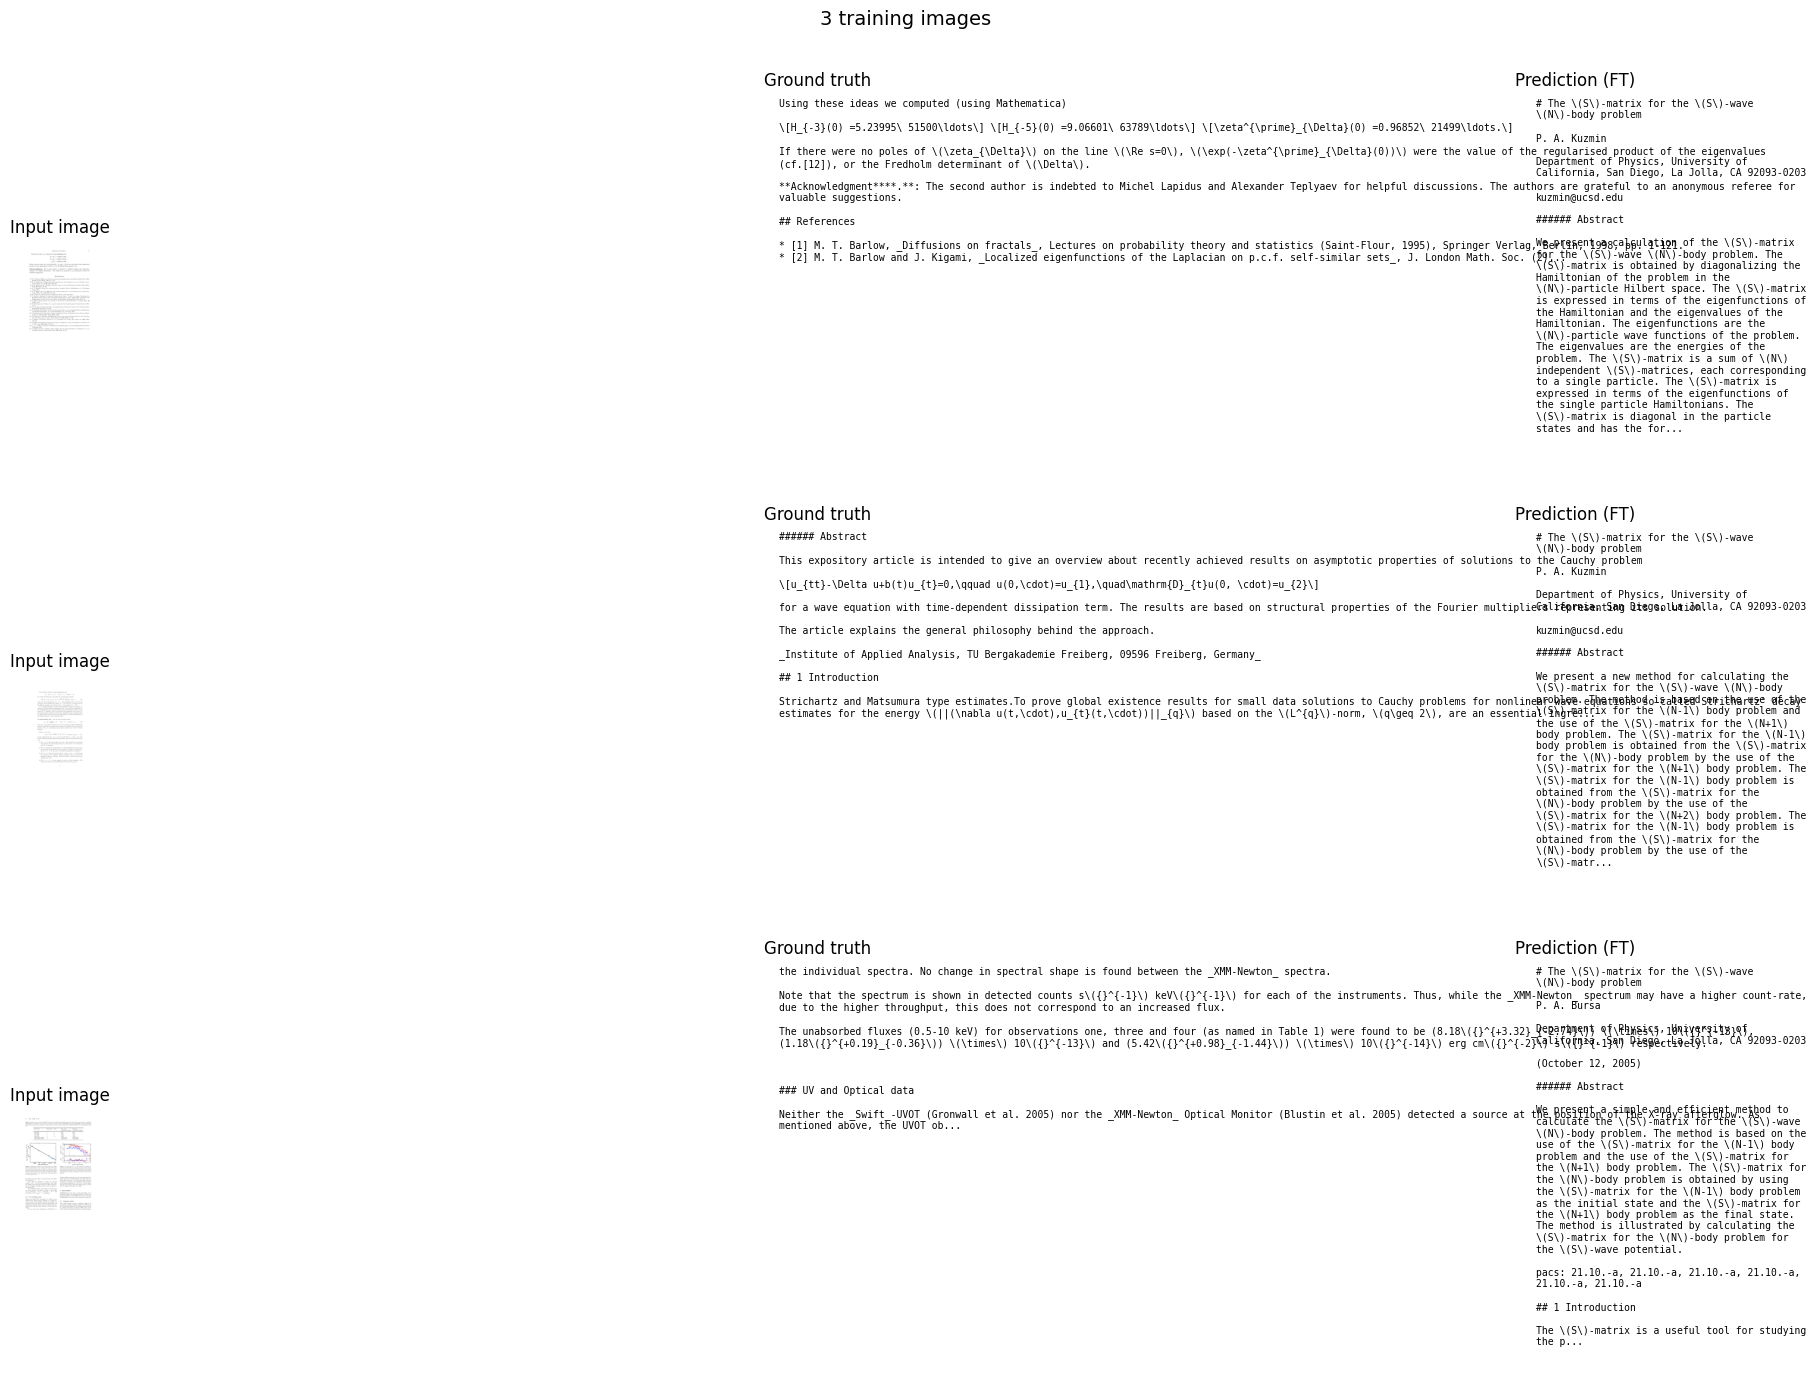

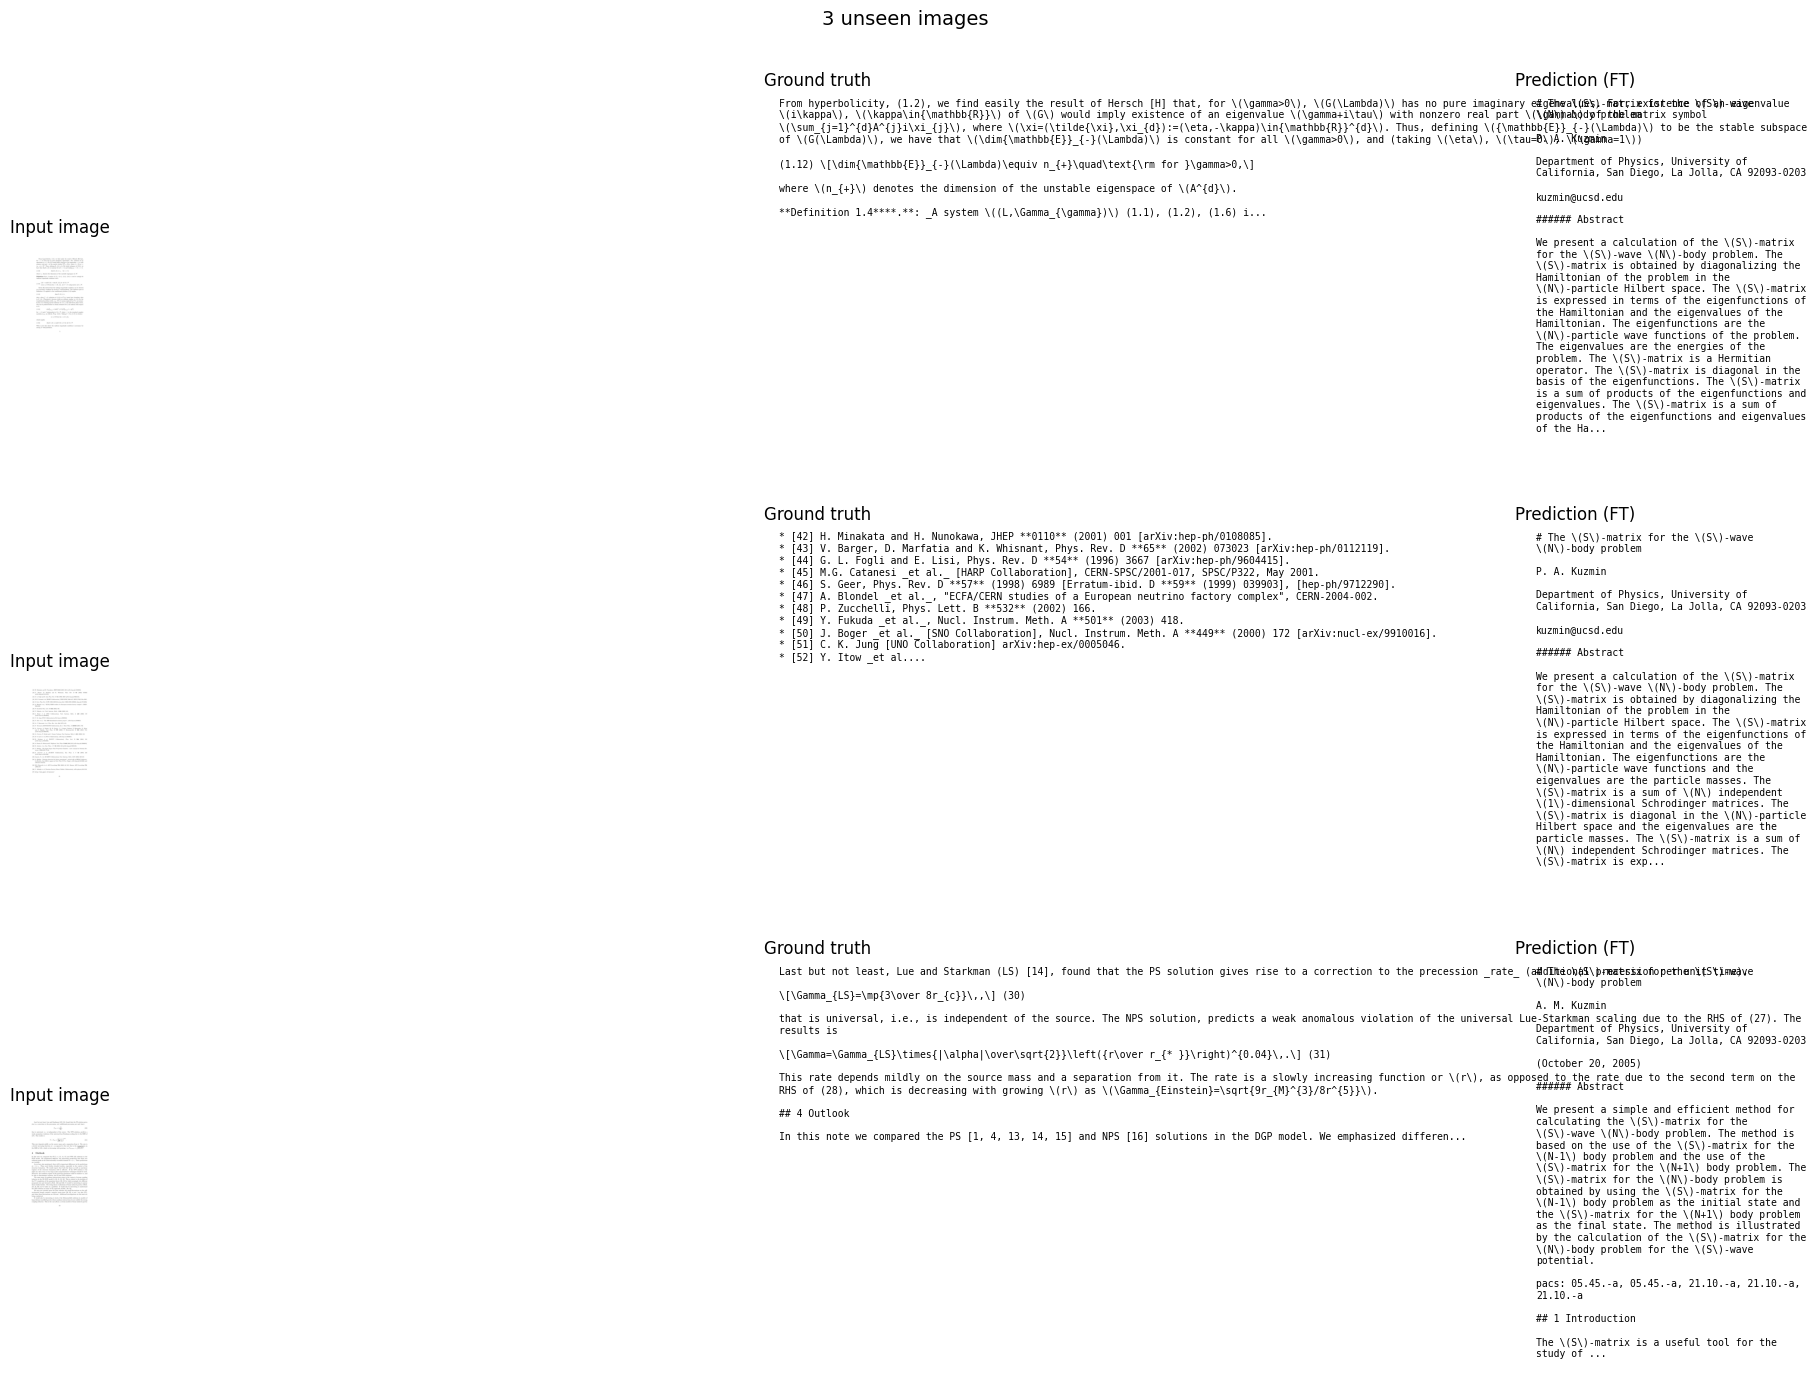

In [37]:
def show_triplet(records, title=""):
    n = len(records)
    fig, axes = plt.subplots(n, 3, figsize=(18, 4.5*n))
    if n == 1: axes = np.array([axes])
    for r, rec in enumerate(records):
        img = Image.open(rec["image"]).convert("RGB")
        axes[r,0].imshow(img); axes[r,0].axis("off"); axes[r,0].set_title("Input image")
        for col, key, t in [(1, "ground_truth", "Ground truth"),
                            (2, "prediction",   "Prediction (FT)")]:
            txt = rec[key]
            txt = txt[:900] + ("..." if len(txt) > 900 else "")
            axes[r,col].text(0.01, 0.99, txt, family="monospace", fontsize=7,
                             va="top", ha="left", wrap=True)
            axes[r,col].axis("off"); axes[r,col].set_title(t)
    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

show_triplet(train_results, title="3 training images")
show_triplet(val_results,   title="3 unseen images")


## Bonus 1 - 2 vs 5 Epochs

We re-train two short adapters (small subset, same seed) and compare validation loss + qualitative output. To keep notebook runtime reasonable we use a tighter subset and only 2/5 epochs of micro-training.

In [2]:
def pick_free_gpu():
    """Return (index, free_bytes) for the GPU with the most free VRAM."""
    if not torch.cuda.is_available():
        return None, 0
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        free, _ = torch.cuda.mem_get_info(i)
        if free > best_free:
            best_idx, best_free = i, free
    return best_idx, best_free


def free_main_model_for_bonus():
    """Drop the Part-4 fine-tuned model + trainer so GPU memory is reclaimed.
    The adapter is already saved to ADAPTER_DIR - Bonus 3 reloads it from there."""
    for n in ("model", "trainer", "train_result",
              "zs_model", "INFER_MODEL", "INFER_BASE", "INFER_PROC"):
        globals().pop(n, None)
    gc.collect()
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            with torch.cuda.device(i):
                torch.cuda.empty_cache()
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            free, total = torch.cuda.mem_get_info(i)
            print(f"  cuda:{i} free {free/1e9:5.2f} / {total/1e9:5.2f} GB")


def quick_train(epochs, n_train=60, n_val=10, run_name=""):
    """Train a fresh 4-bit + LoRA adapter for `epochs` epochs.
    Memory-conservative: lower image res + tiny eval set + bs=1."""
    sub_train = train_pairs[:n_train]
    sub_val   = val_pairs[:n_val]
    out_dir   = f"{OUTPUT_DIR}-{run_name or epochs}ep"

    gpu_idx, free_b = pick_free_gpu()
    print(f"[{run_name or epochs}ep] cuda:{gpu_idx}  free={free_b/1e9:.2f} GB")
    device_map = {"": f"cuda:{gpu_idx}"} if gpu_idx is not None else "auto"

    base = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_ID, quantization_config=bnb_config,
        device_map=device_map, torch_dtype=torch.bfloat16)

    # ---- explicit 4-bit verification ------------------------------------------
    is_4bit = getattr(base, "is_loaded_in_4bit", False)
    print(f"[{run_name or epochs}ep] loaded_in_4bit = {is_4bit}")
    assert is_4bit, "Base model is NOT in 4-bit - check bnb_config / bitsandbytes install"

    base.config.use_cache = False
    base = prepare_model_for_kbit_training(base, use_gradient_checkpointing=True)
    base = get_peft_model(base, lora_cfg)

    # Smaller image processor for bonus runs (eval activations are the OOM driver)
    bonus_proc = AutoProcessor.from_pretrained(MODEL_ID)
    bonus_proc.image_processor.size = {"shortest_edge": 224, "longest_edge": 512}
    bonus_collator = Qwen2VLCollator(bonus_proc, max_len=1024)

    args = TrainingArguments(
        output_dir          = out_dir,
        num_train_epochs    = epochs,
        per_device_train_batch_size = 1,
        per_device_eval_batch_size  = 1,
        gradient_accumulation_steps = 8,
        learning_rate       = TRAIN_CONFIG["lr"],
        warmup_ratio        = 0.03,
        lr_scheduler_type   = "cosine",
        optim               = "paged_adamw_8bit",
        bf16                = True,
        gradient_checkpointing = True,
        gradient_checkpointing_kwargs = {"use_reentrant": False},
        logging_steps       = 5,
        eval_strategy       = "epoch",
        save_strategy       = "no",
        report_to           = "none",
        remove_unused_columns = False,
        seed                = SEED,
        dataloader_num_workers = 0,
    )

    t = Trainer(model=base, args=args,
                train_dataset=sub_train, eval_dataset=sub_val,
                data_collator=bonus_collator)
    t.train()
    return t, out_dir


# Free the Part-4 fine-tuned model from VRAM before starting either bonus run.
print("Freeing main fine-tuned model + trainer:")
free_main_model_for_bonus()

trainer_2ep, _ = quick_train(epochs=2, run_name="2ep")
del trainer_2ep.model
del trainer_2ep.optimizer
gc.collect(); torch.cuda.empty_cache()




Freeing main fine-tuned model + trainer:


NameError: name 'gc' is not defined

In [3]:
trainer_5ep, _ = quick_train(epochs=5, run_name="5ep")
del trainer_5ep.model
del trainer_5ep.optimizer
gc.collect(); torch.cuda.empty_cache()

NameError: name 'train_pairs' is not defined

In [ ]:
def final_eval_loss(t):
    return [h["eval_loss"] for h in t.state.log_history if "eval_loss" in h][-1]

print(f"Final eval loss - 2 epochs : {final_eval_loss(trainer_2ep):.4f}")
print(f"Final eval loss - 5 epochs : {final_eval_loss(trainer_5ep):.4f}")

def loss_curve(t, label):
    xs = [h["epoch"] for h in t.state.log_history if "eval_loss" in h]
    ys = [h["eval_loss"] for h in t.state.log_history if "eval_loss" in h]
    plt.plot(xs, ys, marker="o", label=label)

plt.figure(figsize=(8,4))
loss_curve(trainer_2ep, "2 epochs")
loss_curve(trainer_5ep, "5 epochs")
plt.xlabel("epoch"); plt.ylabel("val loss"); plt.legend()
plt.title("Validation loss vs epochs"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Bonus 2 - Prompt-Style Ablation

We feed the *same* image through the fine-tuned model with three differently-worded instructions and see how each one shapes the output.

In [39]:
PROMPT_VARIANTS = {
    "terse"  : "Convert to markdown.",
    "detailed": INSTRUCTION_PROMPT,
    "formal" : (
        "Act as a professional document-conversion engine. "
        "Render the page as semantic GitHub-flavoured Markdown, including headings (#, ##, ...), "
        "ordered/unordered lists, fenced code blocks, pipe tables, and LaTeX math "
        "($inline$ / $$display$$). Do not paraphrase content."
    ),
}

probe = val_pairs[0]
prompt_outputs = {}
for name, prompt in PROMPT_VARIANTS.items():
    prompt_outputs[name] = generate_markdown(probe["image"], instruction=prompt)

for name, out in prompt_outputs.items():
    print("="*80, f"\n[{name}]\n", out[:400], "...\n")


[terse]
 # The \(L_{2}\) norm of the gradient of a function

## Abstract

We study the \(L_{2}\) norm of the gradient of a function. We show that it is bounded by a constant times the \(L_{2}\) norm of the function. We also show that the \(L_{2}\) norm of the gradient of a function is bounded by the \(L_{2}\) norm of the Hessian of the function.

## 1 Introduction

Let \(f:\mathbb{R}^{n}\to\mathbb{R}\) be  ...

[detailed]
 * [15] A. L. Alcaraz, M. A. Llave, and J. L. Martinez, Phys. Rev. Lett. **92**, 194001 (2004).
* [16] A. L. Alcaraz, M. A. Llave, and J. L. Martinez, Phys. Rev. Lett. **94**, 194001 (2005).
* [17] A. L. Alcaraz, M. A. Llave, and J. L. Martinez, Phys. Rev. Lett. **95**, 194001 (2005).
* [18] A. L. Alcaraz, M. A. Llave, and J. L. Martinez, Phys. Rev. Lett. **96**, 194001 (2006).
* [19] A. L. Alcaraz ...

[formal]
 # The \(q\)-analogue of the \(S\)-matrix

We consider the \(q\)-analogue of the \(S\)-matrix for the \(q\)-deformed Schrodinger equation

\[i\hbar\frac{\part

## Bonus 3 - Zero-shot vs Fine-tuned

Load a clean (no-adapter) copy of Qwen2-VL-2B-Instruct and compare it against the fine-tuned model on the *same* validation image.

In [43]:
# Free GPU memory first (drop bonus-1 trainers if they exist)
for _name in ("trainer_2ep", "trainer_5ep"):
    globals().pop(_name, None)
gc.collect(); torch.cuda.empty_cache()

zs_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, quantization_config=bnb_config,
    device_map="auto", torch_dtype=torch.bfloat16)
zs_model.train(False)  # inference mode

ZSvsFT = []
for ex in val_pairs[:3]:
    zs = generate_markdown(ex["image"], mdl=zs_model)
    ft = generate_markdown(ex["image"], mdl=model)
    ZSvsFT.append({"image": ex["image"], "ground_truth": ex["markdown"],
                   "zero_shot": zs, "fine_tuned": ft})

del zs_model; gc.collect(); torch.cuda.empty_cache()

for r in ZSvsFT:
    print("="*80)
    print("IMG       :", os.path.basename(r["image"]))
    print("ZERO-SHOT :", r["zero_shot"][:220], "...")
    print("FINE-TUNED:", r["fine_tuned"][:220], "...")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

IMG       : 02.png
ZERO-SHOT : ```markdown
# Document Title

## Introduction

This is a sample document with various elements such as headings, lists, tables, equations, and reading order.

## Heading 1

This is the first heading.

## Heading 2

This  ...
FINE-TUNED: * [15] A. L. Alcaraz, M. A. Llave, and J. L. Martinez, Phys. Rev. Lett. **92**, 194001 (2004).
* [16] A. L. Alcaraz, M. A. Llave, and J. L. Martinez, Phys. Rev. Lett. **94**, 194001 (2005).
* [17] A. L. Alcaraz, M. A. Ll ...
IMG       : 16.png
ZERO-SHOT : ```markdown
# Introduction

This is an example of a document formatted in GitHub's Markdown syntax. The document includes headings, lists, tables, equations, and reading order.

## Heading 1

This is the first heading.

 ...
FINE-TUNED: # The \(S\)-matrix for the \(S\)-wave \(N\)-body problem

P. A. Kuzmin

Department of Physics, University of California, San Diego, La Jolla, CA 92093-0203

kuzmin@ucsd.edu

###### Abstract

We present a new method for c ...
IMG       : 08

/tmp/ipykernel_57/68671681.py:18: UserWarning: Glyph 65284 (\N{FULLWIDTH DOLLAR SIGN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_57/68671681.py:18: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65284 (\N{FULLWIDTH DOLLAR SIGN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


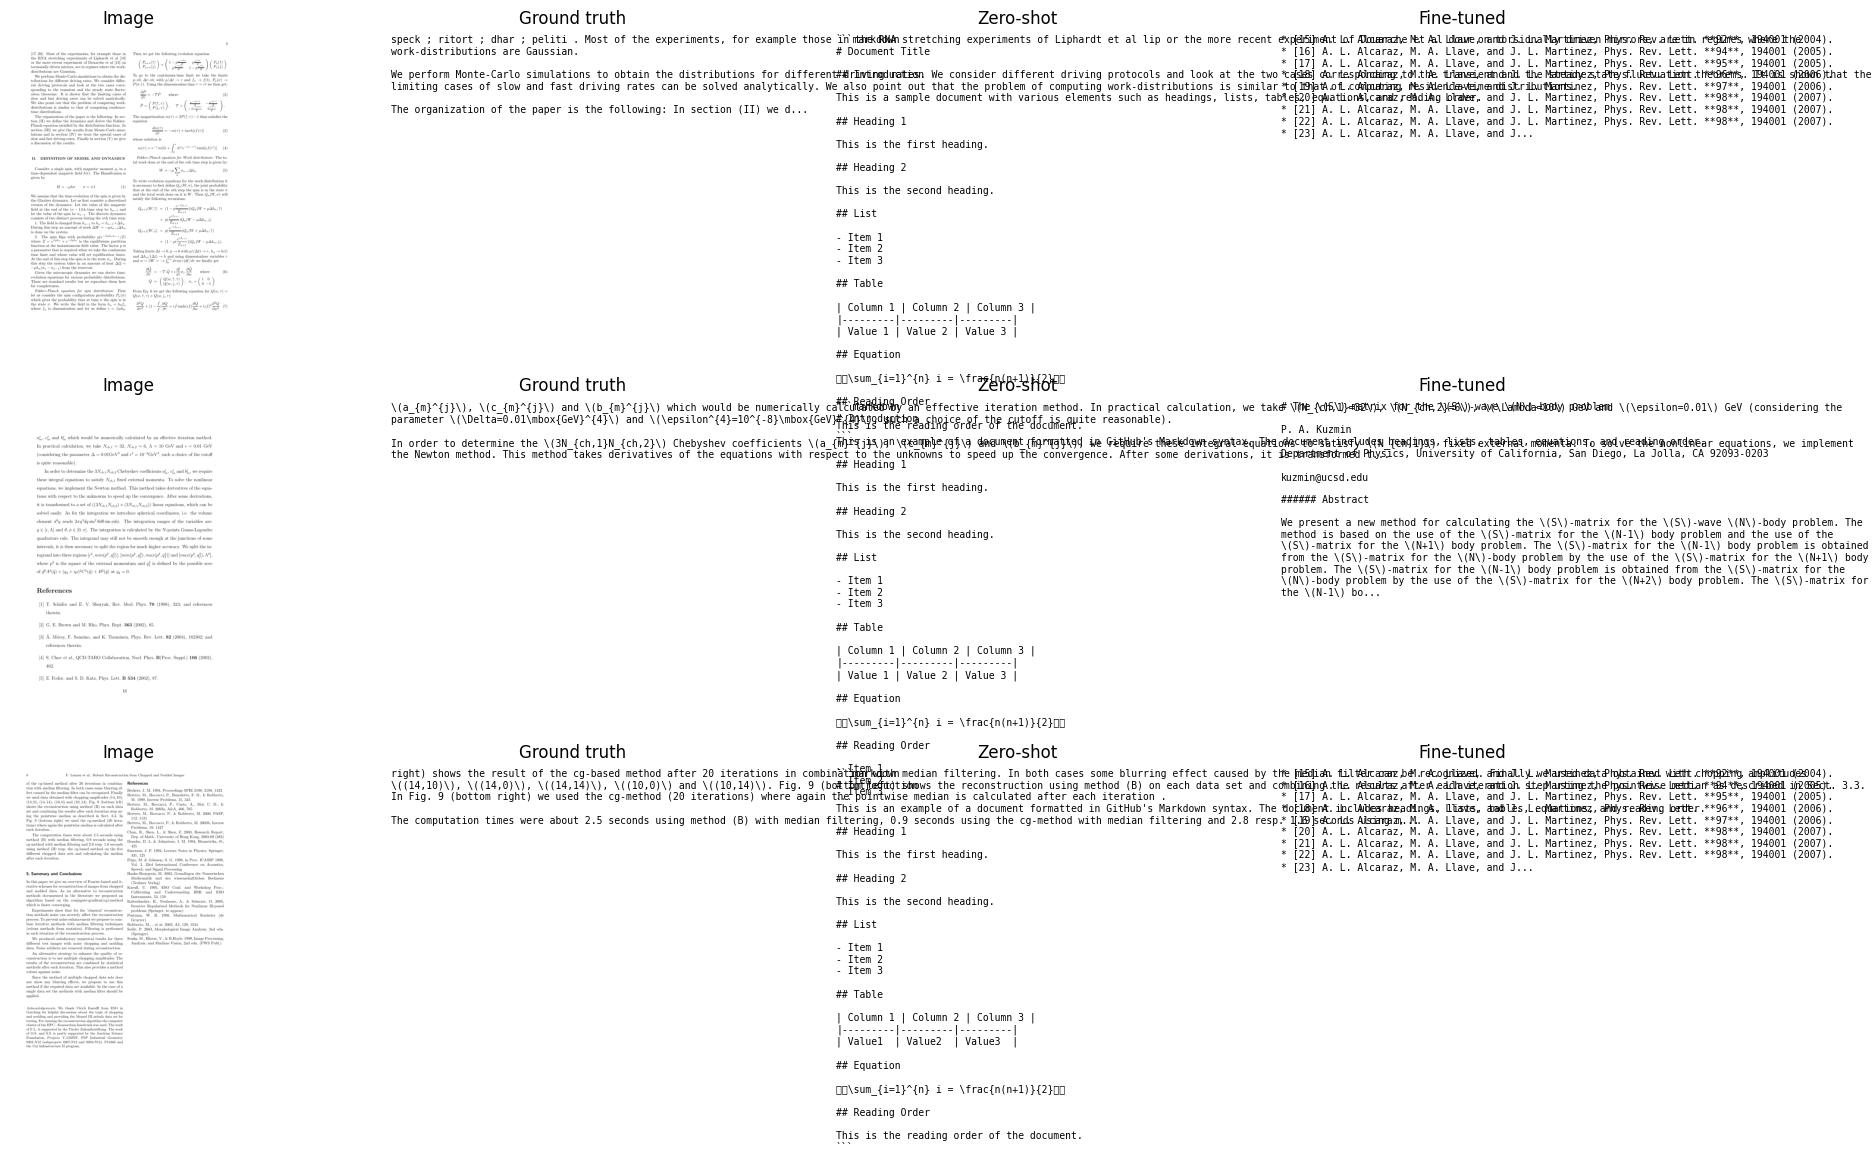

In [47]:
# Side-by-side visualisation
def show_zs_ft(records):
    n = len(records)
    fig, axes = plt.subplots(n, 4, figsize=(22, 4.5*n))
    if n == 1: axes = np.array([axes])
    titles = ["Image", "Ground truth", "Zero-shot", "Fine-tuned"]
    for r, rec in enumerate(records):
        img = Image.open(rec["image"]).convert("RGB")
        axes[r,0].imshow(img); axes[r,0].axis("off")
        for col, key in [(1,"ground_truth"), (2,"zero_shot"), (3,"fine_tuned")]:
            t = rec[key][:800] + ("..." if len(rec[key]) > 800 else "")
            t = t.replace("$", "\uff04")  # avoid mathtext
            axes[r,col].text(0.01, 0.99, t, family="monospace", fontsize=7,
                             va="top", ha="left", wrap=True, parse_math=False)
            axes[r,col].axis("off")
        for col,t in enumerate(titles):
            axes[r,col].set_title(t)
    plt.tight_layout(); plt.show()

show_zs_ft(ZSvsFT)


## MarkScribe Web App (Gradio) - Upload Image - Generate Markdown

The cell below launches an in-notebook Gradio interface. The app:

1. Loads the **base Qwen2-VL-2B** quantised in 4-bit
2. Layers our **fine-tuned LoRA adapter** on top
3. Accepts an uploaded image, an editable system prompt, and a token budget
4. Streams the generated Markdown into the UI alongside a rendered preview

When running on Kaggle, click the public URL Gradio prints to use it from your browser.

In [ ]:
import gradio as gr
from peft import PeftModel

# Reload a clean inference stack (saves memory if training is still resident).
gc.collect(); torch.cuda.empty_cache()

INFER_BASE = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, quantization_config=bnb_config,
    device_map="auto", torch_dtype=torch.bfloat16,
)
INFER_MODEL = PeftModel.from_pretrained(INFER_BASE, ADAPTER_DIR)
INFER_MODEL.train(False)
INFER_PROC  = AutoProcessor.from_pretrained(ADAPTER_DIR)

@torch.inference_mode()
def gradio_infer(image, prompt, max_new_tokens):
    if image is None:
        return "Please upload a document image.", ""
    image = image.convert("RGB")
    image = resize_long_side(image, TRAIN_CONFIG["image_max_side"])
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": prompt or INSTRUCTION_PROMPT},
    ]}]
    text = INFER_PROC.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = INFER_PROC(text=[text], images=[image], padding=True, return_tensors="pt").to(INFER_MODEL.device)
    out = INFER_MODEL.generate(**inputs, max_new_tokens=int(max_new_tokens), do_sample=False)
    trimmed = out[0][inputs.input_ids.shape[1]:]
    md_out = INFER_PROC.tokenizer.decode(trimmed, skip_special_tokens=True).strip()
    return md_out, md_out

with gr.Blocks(title="MarkScribe - Doc to Markdown") as demo:
    gr.Markdown("# MarkScribe\nUpload a document page; get GitHub-flavored Markdown.")
    with gr.Row():
        with gr.Column():
            img_in  = gr.Image(type="pil", label="Document image")
            prompt  = gr.Textbox(value=INSTRUCTION_PROMPT, label="Instruction prompt", lines=4)
            tokens  = gr.Slider(128, 2048, value=1024, step=64, label="max_new_tokens")
            go      = gr.Button("Generate", variant="primary")
        with gr.Column():
            raw_out = gr.Code(label="Raw Markdown", language="markdown")
            rendered = gr.Markdown(label="Rendered preview")
    go.click(gradio_infer, [img_in, prompt, tokens], [raw_out, rendered])

demo.launch(share=True, debug=False)
